In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path
import os

from kornia.augmentation.auto.autoaugment.ops import color

from hloc.utils.viz import save_plot

os.environ['PROJ_LIB'] = '/home/lty/anaconda3/envs/hloc/share/proj'

from osgeo import gdal, osr
from geopy.distance import geodesic

from hloc import extract_features, match_features
from hloc.utils.io import get_matches, get_keypoints
from hloc.visualization import plot_images, plot_keypoints, plot_matches, read_image, add_text

/home/lty/anaconda3/envs/hloc/lib/python3.8/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


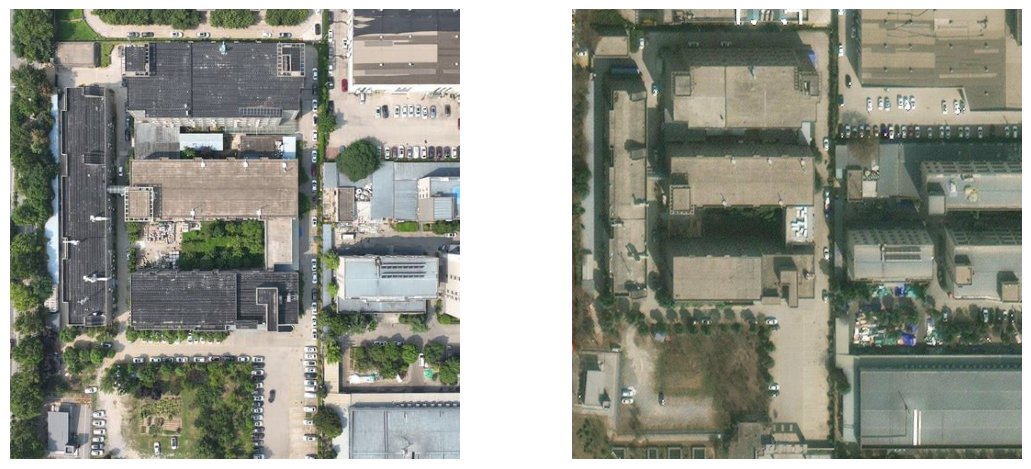

In [2]:
import os
image_dir = Path("/home/lty/test/realuav/city3/")
img_1 = "uav/020.jpg"
img_2 = "tif/146_406_1606.tif"
# img_2 = "seu_uav/DJI_20250109085917_0001_W.JPG"
img_list = [img_1, img_2]
plot_images([read_image(image_dir / img_1), read_image(image_dir / img_2)])

In [3]:
output_dir = Path("output_test")
output_dir.mkdir(exist_ok=True, parents=True)
pairs_path = output_dir / "pairs.txt"

# for the first round of feature extraction and matching
features_1_path = output_dir / "features_1.h5"
matches_1_path = output_dir / "matches_1.h5"

In [4]:
# create pairs file
with open(pairs_path, 'w') as file:
    file.write(f"{img_1} {img_2}")

In [5]:
import time
t1 = time.time()
extract_features.main(
    conf=extract_features.confs["superpoint_max"],
    image_dir=image_dir,
    image_list=img_list,
    feature_path=features_1_path,
)
t2 = time.time()
match_features.main(
    conf=match_features.confs["superpoint+lightglue"],
    pairs=pairs_path,
    features=features_1_path,
    matches=matches_1_path,
)
t3 = time.time()
print(f"特征提取耗时：{t2 - t1:.2f} 秒")
print(f"特征匹配耗时：{t3 - t2:.2f} 秒")

[2025/05/18 14:58:48 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 4096, 'name': 'superpoint', 'nms_radius': 3},
 'output': 'feats-superpoint-n4096-rmax1600',
 'preprocessing': {'grayscale': True, 'resize_force': True, 'resize_max': 1600}}
[2025/05/18 14:58:48 hloc INFO] Skipping the extraction.
[2025/05/18 14:58:48 hloc INFO] Matching local features with configuration:
{'model': {'features': 'superpoint', 'name': 'lightglue'},
 'output': 'matches-superpoint-lightglue'}
[2025/05/18 14:58:48 hloc INFO] Skipping the matching.


特征提取耗时：0.02 秒
特征匹配耗时：0.00 秒


In [6]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from hloc.utils.io import read_features
from hloc.visualization import plot_images, plot_keypoints
from pathlib import Path

# 图像路径
image_dir = Path("/home/lty/test/realuav/city2/")
img_1 = "uav/001.jpg"
img_2 = "seu_tif/131_856_1606.tif"
features_1_path = Path("output_test/features_1.h5")

# 读取图像
from hloc.utils.io import read_image
images = [read_image(image_dir / img_1), read_image(image_dir / img_2)]
plot_images(images)

# 读取关键点和分数
feat1 = load_features(features_1_path, img_1)
feat2 = load_features(features_1_path, img_2)

kpts1, scores1 = feat1["keypoints"], feat1["scores"]
kpts2, scores2 = feat2["keypoints"], feat2["scores"]

# 使用 colormap 映射分数到颜色（归一化）
norm = mcolors.Normalize(vmin=min(scores1.min(), scores2.min()), vmax=max(scores1.max(), scores2.max()))
cmap = cm.get_cmap("plasma")

colors1 = [cmap(norm(score)) for score in scores1]
colors2 = [cmap(norm(score)) for score in scores2]

# 绘制关键点（使用颜色列表）
plot_keypoints([kpts1, kpts2], colors=[colors1, colors2], ps=2)

# 显示
plt.show()


ImportError: cannot import name 'read_features' from 'hloc.utils.io' (/home/lty/ch4/hloc/utils/io.py)

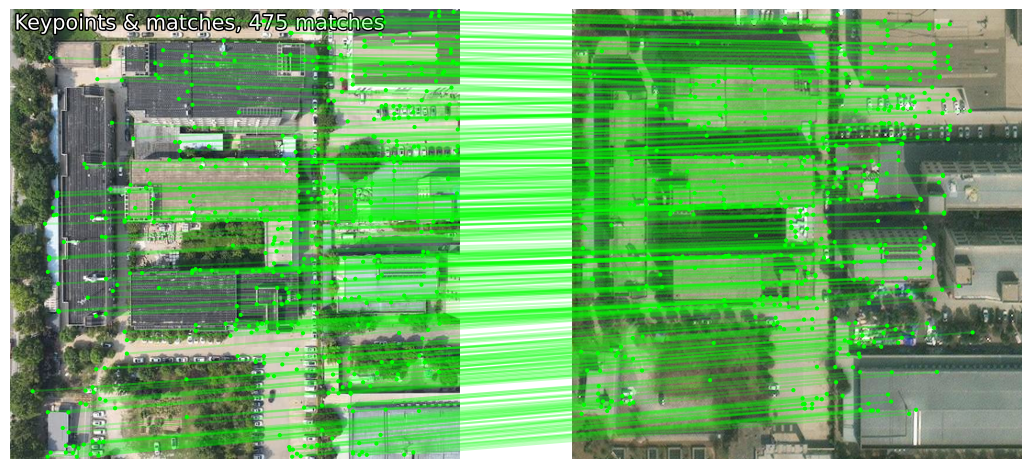

In [7]:
kp1, kp2  = get_keypoints(features_1_path, img_1), get_keypoints(features_1_path, img_2)
matches, scores = get_matches(matches_1_path, img_1, img_2)
plot_images([read_image(image_dir / img) for img in img_list])
plot_matches(kp1[matches[:,0]], kp2[matches[:,1]], a=0.25, color=(0, 1, 0))
add_text(0, f"Keypoints & matches, {matches.shape[0]} matches")
#save the plot
plt.savefig("matches.png", bbox_inches="tight", pad_inches=0, transparent=False)


In [8]:
print(kp1.shape)
print(kp2.shape)
print(matches.shape)
print(scores.shape)

(3931, 2)
(1877, 2)
(475, 2)
(475,)


show H inliers

[[ 1.31599588e+00  5.31464286e-02 -1.32968131e+01]
 [-1.18460276e-02  1.39796175e+00  2.41860839e+01]
 [-7.09946160e-05  8.63345879e-05  1.00000000e+00]]
131
内点数量：131/475


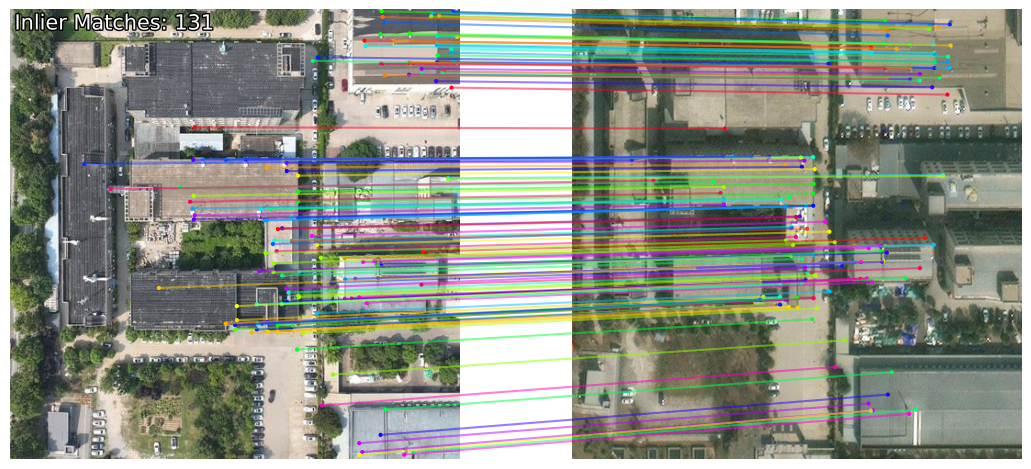

In [10]:
pts1 = kp1[matches[:,0]]
pts2 = kp2[matches[:,1]]

H, mask = cv2.findHomography(pts1, pts2, cv2.RANSAC, 5.0)#mask:
print(H)
inliers = mask.ravel().tolist()
num_inliers = np.sum(inliers)
print(num_inliers)
# 将 mask 转换为一维布尔数组
inliers = mask.ravel().astype(bool)

# 提取内点匹配对
pts1_inliers = pts1[inliers]
pts2_inliers = pts2[inliers]

# 提取外点匹配对（可选）
pts1_outliers = pts1[~inliers]
pts2_outliers = pts2[~inliers]

# 计算内点数量
num_inliers = np.sum(inliers)
print(f"内点数量：{num_inliers}/{len(pts1)}")

# 可视化内点匹配（例如，使用之前的 plot_matches 函数）
plot_images([read_image(image_dir / img) for img in img_list])
plot_matches(pts1_inliers, pts2_inliers, a=0.5)
add_text(0, f"Inlier Matches: {num_inliers}")
plt.savefig("inlier_matches.png", bbox_inches="tight", pad_inches=0, transparent=False)

无人机图像中心点：[[245. 245.]]
无人机图像中心点在大图中的齐次坐标：[322.1430537  363.78443473   1.00375829]
无人机图像中心点在大图中的位置：[320.93687884 362.42234533]
size: (490, 490, 3)


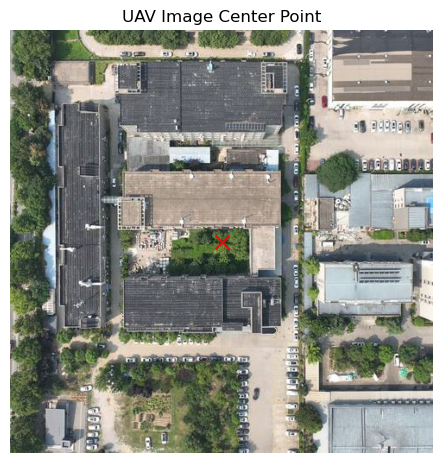

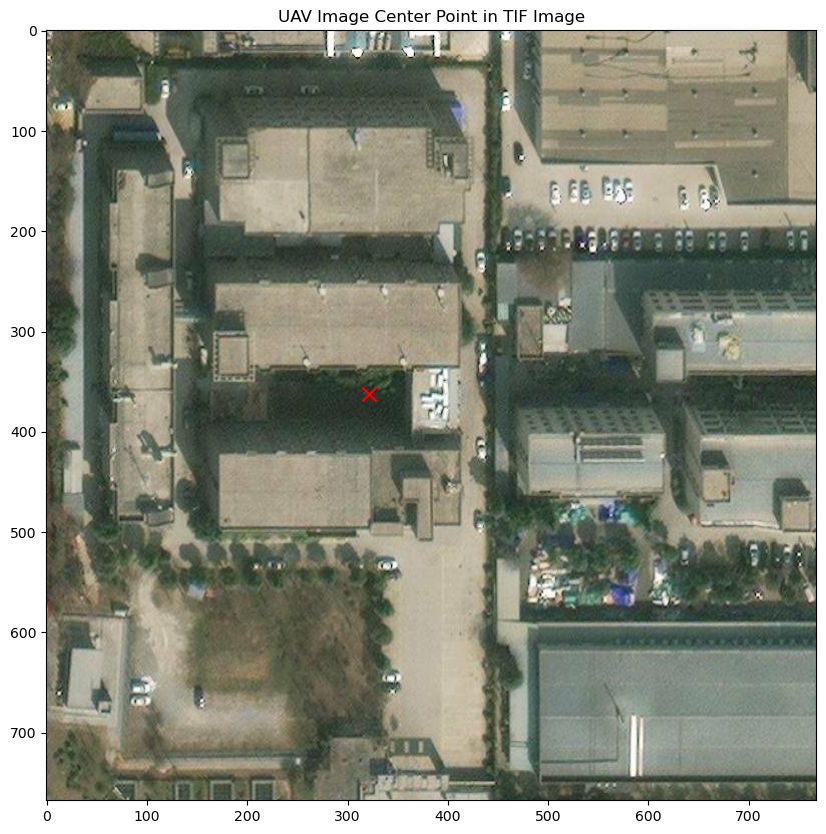

In [11]:
if H is not None:
    # 获取无人机图像的尺寸
    uav_image = read_image(image_dir / img_1)
    h_uav, w_uav = uav_image.shape[:2]

    # 计算无人机图像的中心点坐标
    center_uav = np.array([[w_uav / 2, h_uav / 2]], dtype=np.float32)  # 形状为 (1, 2)
    print(f"无人机图像中心点：{center_uav}")
    center_uav[0][1] = center_uav[0][1]

    # 将中心点坐标转换为齐次坐标
    center_uav_homogeneous = np.array([center_uav[0][0], center_uav[0][1], 1.0])  # 形状为 (3,)

    # 通过单应性矩阵进行变换
    center_tif_homogeneous = np.dot(H, center_uav_homogeneous)  # 形状为 (3,)
    print(f"无人机图像中心点在大图中的齐次坐标：{center_tif_homogeneous}")

    # 归一化
    center_tif = center_tif_homogeneous[:2] / center_tif_homogeneous[2]  # 形状为 (2,
    # center_tif = center_tif_homogeneous[:2] / 1  # 形状为 (2,
    # 
    # 打印结果
    print(f"无人机图像中心点在大图中的位置：{center_tif}")
        # 绘制无人机图像中心点在无人机图像上的位置
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(uav_image)
    plt.scatter(center_uav[0][0], center_uav[0][1], c='r', s=100, marker='x')  # 绘制中心点
    plt.title('UAV Image Center Point')
    plt.axis('off')
    plt.savefig("uav_image_center.png", bbox_inches="tight", pad_inches=0, transparent=False)
    print("size:", uav_image.shape)
    # 可视化结果
    tif_image = read_image(image_dir / img_2)
    plt.figure(figsize=(10, 10))
    plt.imshow(tif_image)
    plt.scatter(center_tif[0], center_tif[1], c='r', s=100, marker='x')  # 绘制中心点
    plt.title('UAV Image Center Point in TIF Image')
    plt.axis('on')
    plt.savefig("tif_image_center.png", bbox_inches="tight", pad_inches=0, transparent=False)
    plt.show()
    
else:
    print("无法计算单应性矩阵。")

In [12]:
geotransform = []
# 打开 geotransform.txt 文件
with open("/home/lty/datasets/RealUAV/city3/geotransform.txt", "r") as f:
    # 逐行读取文件内容
    for line in f:
        # 去除行首尾的空白字符和换行符
        line = line.strip()
        if line:
            try:
                # 将字符串转换为浮点数
                value = float(line)
                # 将数值添加到列表中
                geotransform.append(value)
            except ValueError:
                print(f"无法将以下内容转换为数值：'{line}'")
                # 根据需要，可以选择跳过或停止程序
                continue
# 输出读取到的 geotransform 数据
print("Geotransform 数组：\n", geotransform)

Geotransform 数组：
 [12117256.345935825, 0.2985821417389691, 0.0, 4055825.1578397285, 0.0, -0.2985821417389691]


In [26]:
# geo coordinates
tif_name = os.path.basename(img_2)
print(tif_name)
start_x = start_y = None
# 使用正则表达式匹配以数字开头的部分
match = re.match(r"(\d+)_(\d+)_(\d+).tif", tif_name)
if match:
    tif_id = match.group(1)
    start_x = match.group(2)
    start_y = match.group(3)
    print(f"TIFF ID: {tif_id}")
    print(f"起始横坐标：{start_x}")
    print(f"起始纵坐标：{start_y}")
else:
    print("无法从文件名中提取 TIFF ID")
x_in_map = int(start_x) + center_tif[0]
y_in_map = int(start_y) + center_tif[1]
print(f"大图中的位置：({x_in_map}, {y_in_map})")
source_srs = None
lon,lat = None, None
x_geo, y_geo = None, None
print("地理变换参数:", geotransform)

source_srs = osr.SpatialReference()
# source_srs.ImportFromWkt(proj)
source_srs.ImportFromEPSG(3857)
target_srs = osr.SpatialReference()
target_srs.ImportFromEPSG(4326)
if geotransform:
    # 获取仿射变换参数
    x_origin, x_pixel_size, x_rotation, y_origin, y_rotation, y_pixel_size = geotransform
    # 计算地理坐标
    x_geo = x_origin + x_pixel_size * x_in_map
    y_geo = y_origin + y_pixel_size * y_in_map
    print(f"地理坐标32650：({x_geo}, {y_geo})")

    x_geo = 12117469.7779
    y_geo = 4055236.0171
    coord_transform = osr.CoordinateTransformation(source_srs, target_srs)
    lat, lon, _ = coord_transform.TransformPoint(x_geo, y_geo)
    print(f"经度：{lon}, 纬度：{lat}")


146_406_1606.tif
TIFF ID: 146
起始横坐标：406
起始纵坐标：1606
大图中的位置：(726.9368788403119, 1968.4223453316795)
地理变换参数: [12117256.345935825, 0.2985821417389691, 0.0, 4055825.1578397285, 0.0, -0.2985821417389691]
地理坐标32650：(12117473.39630602, 4055237.4220800125)
经度：108.85308306343953, 纬度：34.196635412051606


In [27]:
def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points
    on the earth (specified in decimal degrees)
    """
    # convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    # Radius of earth in kilometers is 6371
    km = 6371000.0 * c
    print(f"haversine 两点之间的距离：{km:.2f} 米")

In [28]:
re_lon = 108.85309
re_lat = 34.19677

re_x_geo = 12117470.55007438
re_y_geo = 4055254.131025581
# re_x_geo = 12117469.436879473#021
# re_y_geo = 4055258.1686701435
# lat = 32.05885506
# lon = 118.7873626344
point1 = (re_lat, re_lon)
point2 = (lat, lon)
distance = geodesic(point1, point2).meters
print(f"两点之间的距离：{distance:.2f} 米")
haversine(re_lon, re_lat, lon, lat)
d = np.sqrt((re_x_geo - x_geo)**2 + (re_y_geo - y_geo)**2)
print(f"32650:两点之间的距离：{d:.2f} 米")

两点之间的距离：14.94 米
haversine 两点之间的距离：14.98 米
32650:两点之间的距离：18.13 米
